## Task1

In [1]:
import sympy as sp
import numpy as np
import time as t
!pip install plotnine
from plotnine import *
import pandas as pd

Defaulting to user installation because normal site-packages is not writeable
    pytz (>=2011n)
         ~~~~~~~^


In [19]:

x1, x2 = sp.symbols('x1 x2')
func = 100 * (x2 - x1**2)**2 + (1 - x1)**2
df_dx1 = sp.diff(func, x1)
df_dx2 = sp.diff(func, x2)
objective_func = sp.lambdify((x1, x2), func, 'numpy')
gradient_func = sp.lambdify((x1, x2), [df_dx1, df_dx2], 'numpy')

def calculate_objective(x:np.array)->float:
    return objective_func(x[0], x[1])

def calculate_gradient(x: np.array):
    return np.array(gradient_func(x[0], x[1]))

def gradient_descent(step:float, error =1e-4, max_iter = 10_000_000):
    x = np.array([-2, 2])
    objective_values = []
    time_start = t.time()
    for i in range(max_iter):
        grad = calculate_gradient(x)
        next_x = x - step * grad
        objective_values.append(calculate_objective(next_x))
        if  (np.linalg.norm(grad) < error) or (np.linalg.norm(next_x) > 1e20) :
            break
        x = next_x

    finish_time = t.time() - time_start
    return objective_values, finish_time




In [3]:
df_dx2

-200*x1**2 + 200*x2

In [23]:
steps = [0.01, 0.0001, 0.00001]
all_objective_values = pd.DataFrame(columns=['objective_value', 'iteration', 'step'])
for step in steps:
    objective_values, time = gradient_descent(step, max_iter =10_000_000)
    print(f'for step {step} it took {time} and itterations: {len(objective_values)} for this final result {objective_values[-1]}')
    temp_df = pd.DataFrame({
        'objective_value': objective_values,
        'iteration': np.arange(1, len(objective_values) + 1),
        'step': str(step)
    })

    all_objective_values = pd.concat([all_objective_values, temp_df], ignore_index=True)



for step 0.01 it took 0.000682830810546875 and itterations: 4 for this final result 6.13206683312745e+156


/tmp/ipykernel_16131/4074734921.py:12: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.


for step 0.0001 it took 4.892388582229614 and itterations: 212526 for this final result 1.2515870833245025e-08
for step 1e-05 it took 18.22638463973999 and itterations: 2125469 for this final result 1.2517642032158144e-08


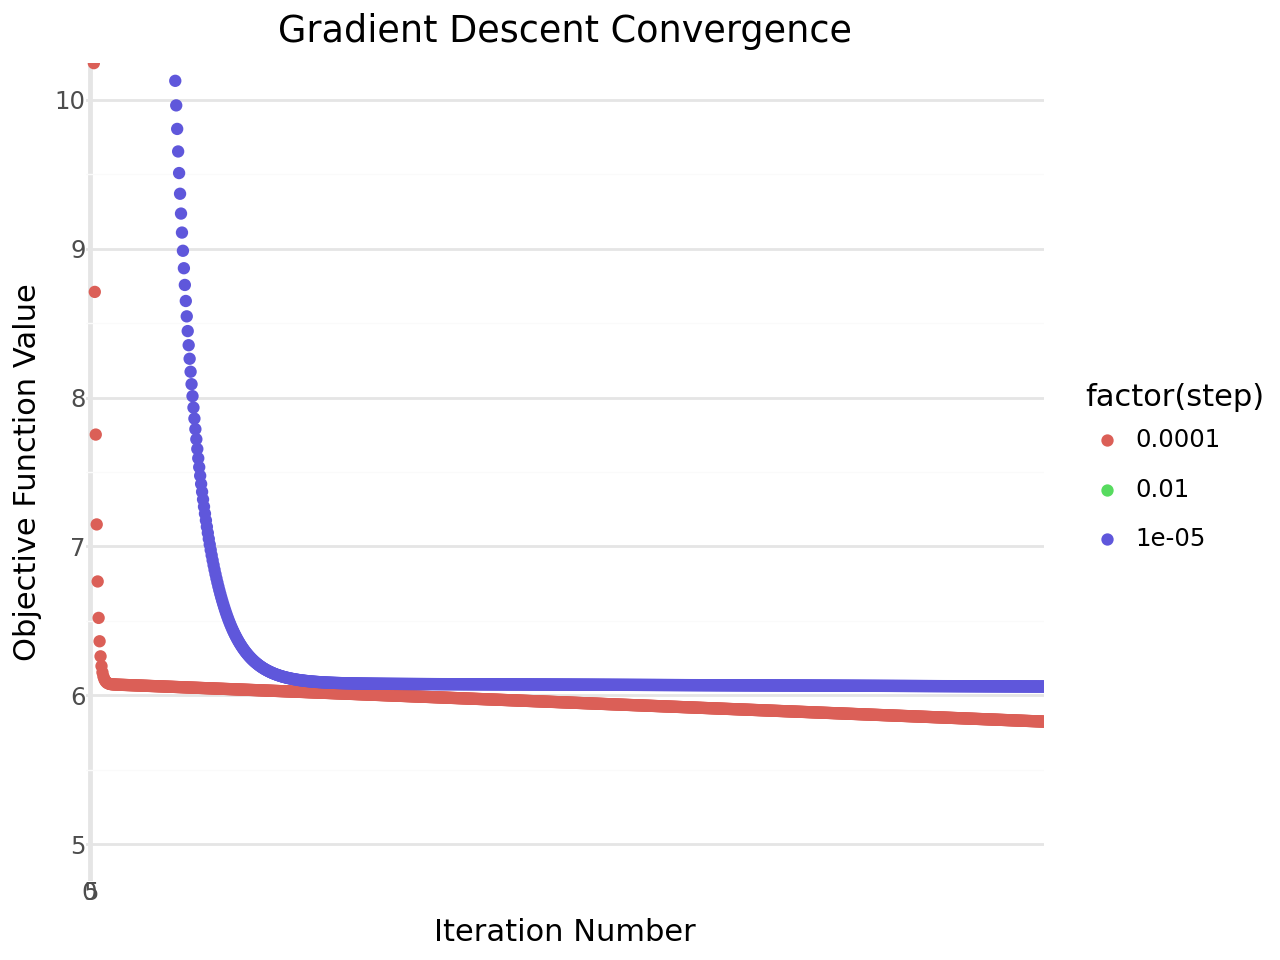

In [17]:
fig = (ggplot(all_objective_values, aes(x="iteration", y="objective_value", color="factor(step)")) +
       geom_point() +
       labs(title="Gradient Descent Convergence", x="Iteration Number", y="Objective Function Value") +
        coord_cartesian(xlim=(0,5), ylim=(5, 10)) +
       theme_minimal())
fig

## Task2

In [38]:
df = pd.read_csv("Concrete_Data.csv")
A = df.iloc[:, :3].to_numpy()
A = (A - np.mean(A, axis=0)) / np.std(A, axis=0)
# b = np.array([0]*1030)
b = df.iloc[:, -1].to_numpy().reshape(-1, 1)
b = (b - np.mean(b, axis=0)) / np.std(b, axis=0)
m = b.shape[0]
n = A.shape[1]

array([0, 0, 0, ..., 0, 0, 0])

In [33]:
def lse_func(A:np.array, b:np.array, x:np.array) -> np.array:
    return (1 / (2 * m)) * np.linalg.norm(A @ x - b)**2

def calculate_gradient_lse(A:np.array, b:np.array, x:np.array):
    return A.T @ (A@ x -b)/m

def gradient_descent_lse(step:float, error =1e-4, max_iter = 50):
    x = np.zeros((n, 1))
    objective_values = []
    time_start = t.time()
    for i in range(max_iter):
        grad = calculate_gradient_lse(A, b, x)
        next_x = x - step * grad
        objective_values.append(lse_func(A, b, next_x))
        if  np.linalg.norm(grad) < error :
            break
        x = next_x

    finish_time = t.time() - time_start
    return objective_values, finish_time


In [39]:
L_1 = np.linalg.norm(A, 2)/m
L_2 = (1 / A.shape[0]) * (np.linalg.norm(A.T @ A, 2) * 20 + np.linalg.norm(A.T @ b, 2))

steps_lse = [0.001, 0.0001, 1/(L_1), 1/(L_2)]
all_objective_values_lse = pd.DataFrame(columns=['objective_value', 'iteration', 'step'])
i = 0
for st in steps_lse:
    objective_values, _ = gradient_descent_lse(st, max_iter=20)
    print(f"Step {st}: {len(objective_values)} iterations")

    temp_df = pd.DataFrame({
        'objective_value': objective_values,
        'iteration': np.arange(1, len(objective_values) + 1),
        'step': f'{st}'
    })
    if i!=2:
        all_objective_values_lse = pd.concat([all_objective_values_lse, temp_df], ignore_index=True)
    i+=1

Step 0.001: 20 iterations
Step 0.0001: 20 iterations
Step 27.085816523747884: 20 iterations
Step 0.034958179408063214: 20 iterations


/tmp/ipykernel_16131/3056538574.py:17: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.


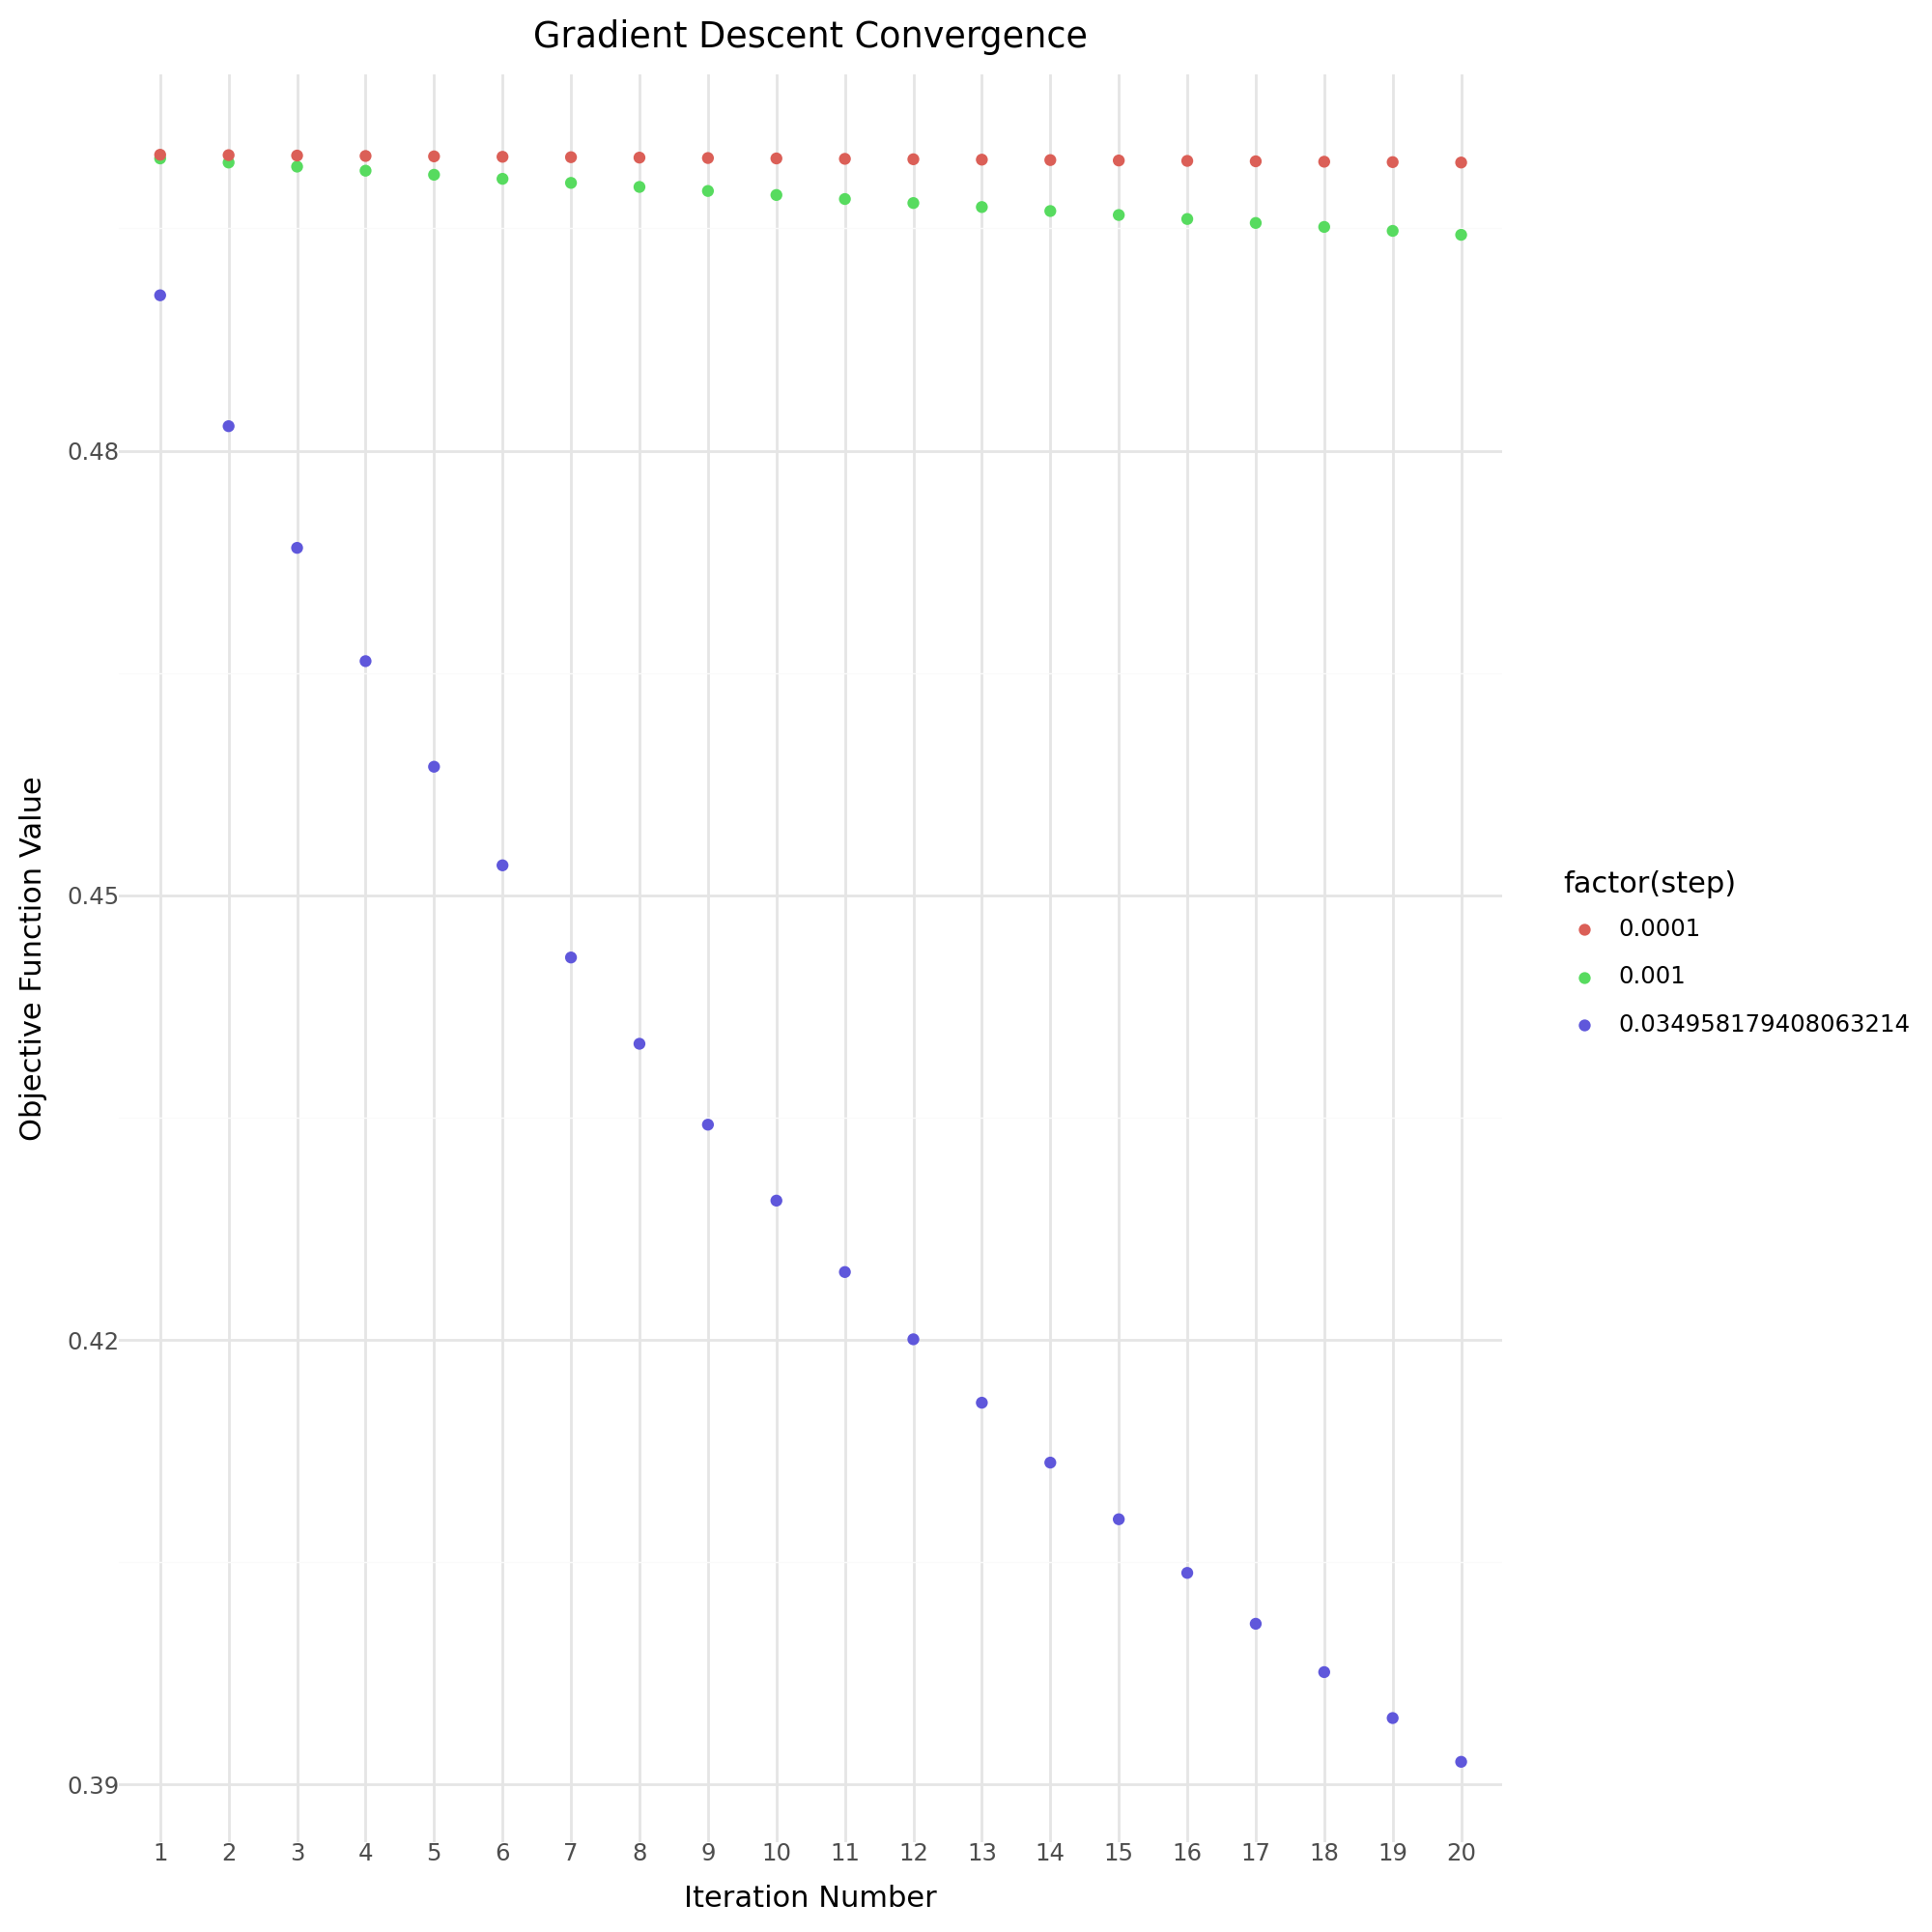

In [40]:
fig_1 = (ggplot(all_objective_values_lse, aes(x="iteration", y="objective_value", color="factor(step)")) +
       geom_point() +
       labs(title="Gradient Descent Convergence", x="Iteration Number", y="Objective Function Value") +
        # coord_cartesian(xlim=(1, 20), ylim=(0.4, 0.6)) +
       theme_minimal()+
         theme(figure_size = (10, 10)))
fig_1

## Task 3

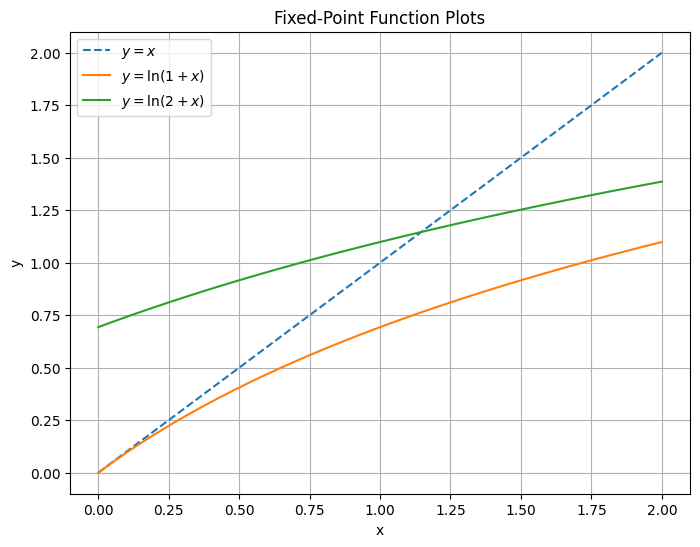

In [10]:
import matplotlib.pyplot as plt
x = np.linspace(0, 2, 100)
y1 = x
y2 = np.log(1 + x)
y3 = np.log(2 + x)

plt.figure(figsize=(8, 6))
plt.plot(x, y1, label=r'$y = x$', linestyle='--')
plt.plot(x, y2, label=r'$y = \ln(1 + x)$')
plt.plot(x, y3, label=r'$y = \ln(2 + x)$')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Fixed-Point Function Plots')
plt.legend()
plt.grid(True)

plt.show()


In [113]:
import numpy as np
from scipy.optimize import minimize_scalar
#find derivatives

def gradient_descent_ln(step:float, func, gradient, error =1e-5, max_iter =100):
    x = 0.5
    objective_values = []
    time_start = t.time()
    for i in range(max_iter):
        print("i", i, "x", x)
        grad = gradient(x)
        next_x = x - step * grad
        objective_values.append(func(next_x))
        if  np.linalg.norm(grad) < error :
            break
        x = next_x

    finish_time = t.time() - time_start
    return objective_values, finish_time, x



In [105]:
def minus_g1(x):
    return -((x - np.log(1 + x)) * (1 - (1 / (1 + x))))

def minus_g2(x):
    return -((x - np.log(2 + x)) * (1 - (1 / (2 + x))))

def g1(x):
    return 0.5 * (x - np.log(1 + x))**2

def grad_g1(x):
    return (x - np.log(1 + x)) * (1 - (1 / (1 + x)))

def g2(x):
    return 0.5 * (x - np.log(2 + x))**2

def grad_g2(x):
    return (x - np.log(2 + x)) * (1 - (1 / (2 + x)))

def max_value(func):
    result = minimize_scalar(func, bounds=(0, 2), method='bounded')
    print(result)
    return -result.fun

l_1 = max_value(minus_g1)
l_2 = max_value(minus_g2)

 message: Solution found.
 success: True
  status: 0
     fun: -0.6009229597545602
       x: 1.9999959949686341
     nit: 27
    nfev: 27
 message: Solution found.
 success: True
  status: 0
     fun: -0.46027682271151693
       x: 1.9999959949686341
     nit: 27
    nfev: 27


In [114]:
values_1, time_1, x_1 = gradient_descent_ln(1/l_1,g1, grad_g1)
values_2, time_2, x_2 = gradient_descent_ln(1/l_2,g2, grad_g2)


i 0 x 0.5
i 1 x 0.447561280328709
i 2 x 0.4075933512450039
i 3 x 0.3759286474195161
i 4 x 0.3501038308601967
i 5 x 0.32856085280130476
i 6 x 0.31026175886588103
i 7 x 0.29448603381571403
i 8 x 0.2807164970244704
i 9 x 0.26857146138180543
i 10 x 0.2577625520664358
i 11 x 0.2480674776696822
i 12 x 0.23931188355807775
i 13 x 0.23135692090774473
i 14 x 0.22409052464785806
i 15 x 0.21742116340342124
i 16 x 0.2112732763693811
i 17 x 0.20558388576261738
i 18 x 0.2003000440148793
i 19 x 0.19537688378253604
i 20 x 0.19077610999124314
i 21 x 0.1864648205544388
i 22 x 0.1824145745999322
i 23 x 0.1786006492667298
i 24 x 0.17500144171800833
i 25 x 0.17159798409713622
i 26 x 0.16837354713623115
i 27 x 0.16531331394705676
i 28 x 0.16240410981559772
i 29 x 0.1596341770191254
i 30 x 0.1569929860901867
i 31 x 0.15447107677836944
i 32 x 0.1520599233592626
i 33 x 0.14975182001958834
i 34 x 0.1475397828871179
i 35 x 0.1454174659316797
i 36 x 0.14337908848222897
i 37 x 0.1414193725165743
i 38 x 0.1395334882

In [99]:
print(x_1)
print(x_2)

0.15429455769261705
1.146014365675913


Time for first func: 0.0022430419921875
Time for first func: 0.0007398128509521484


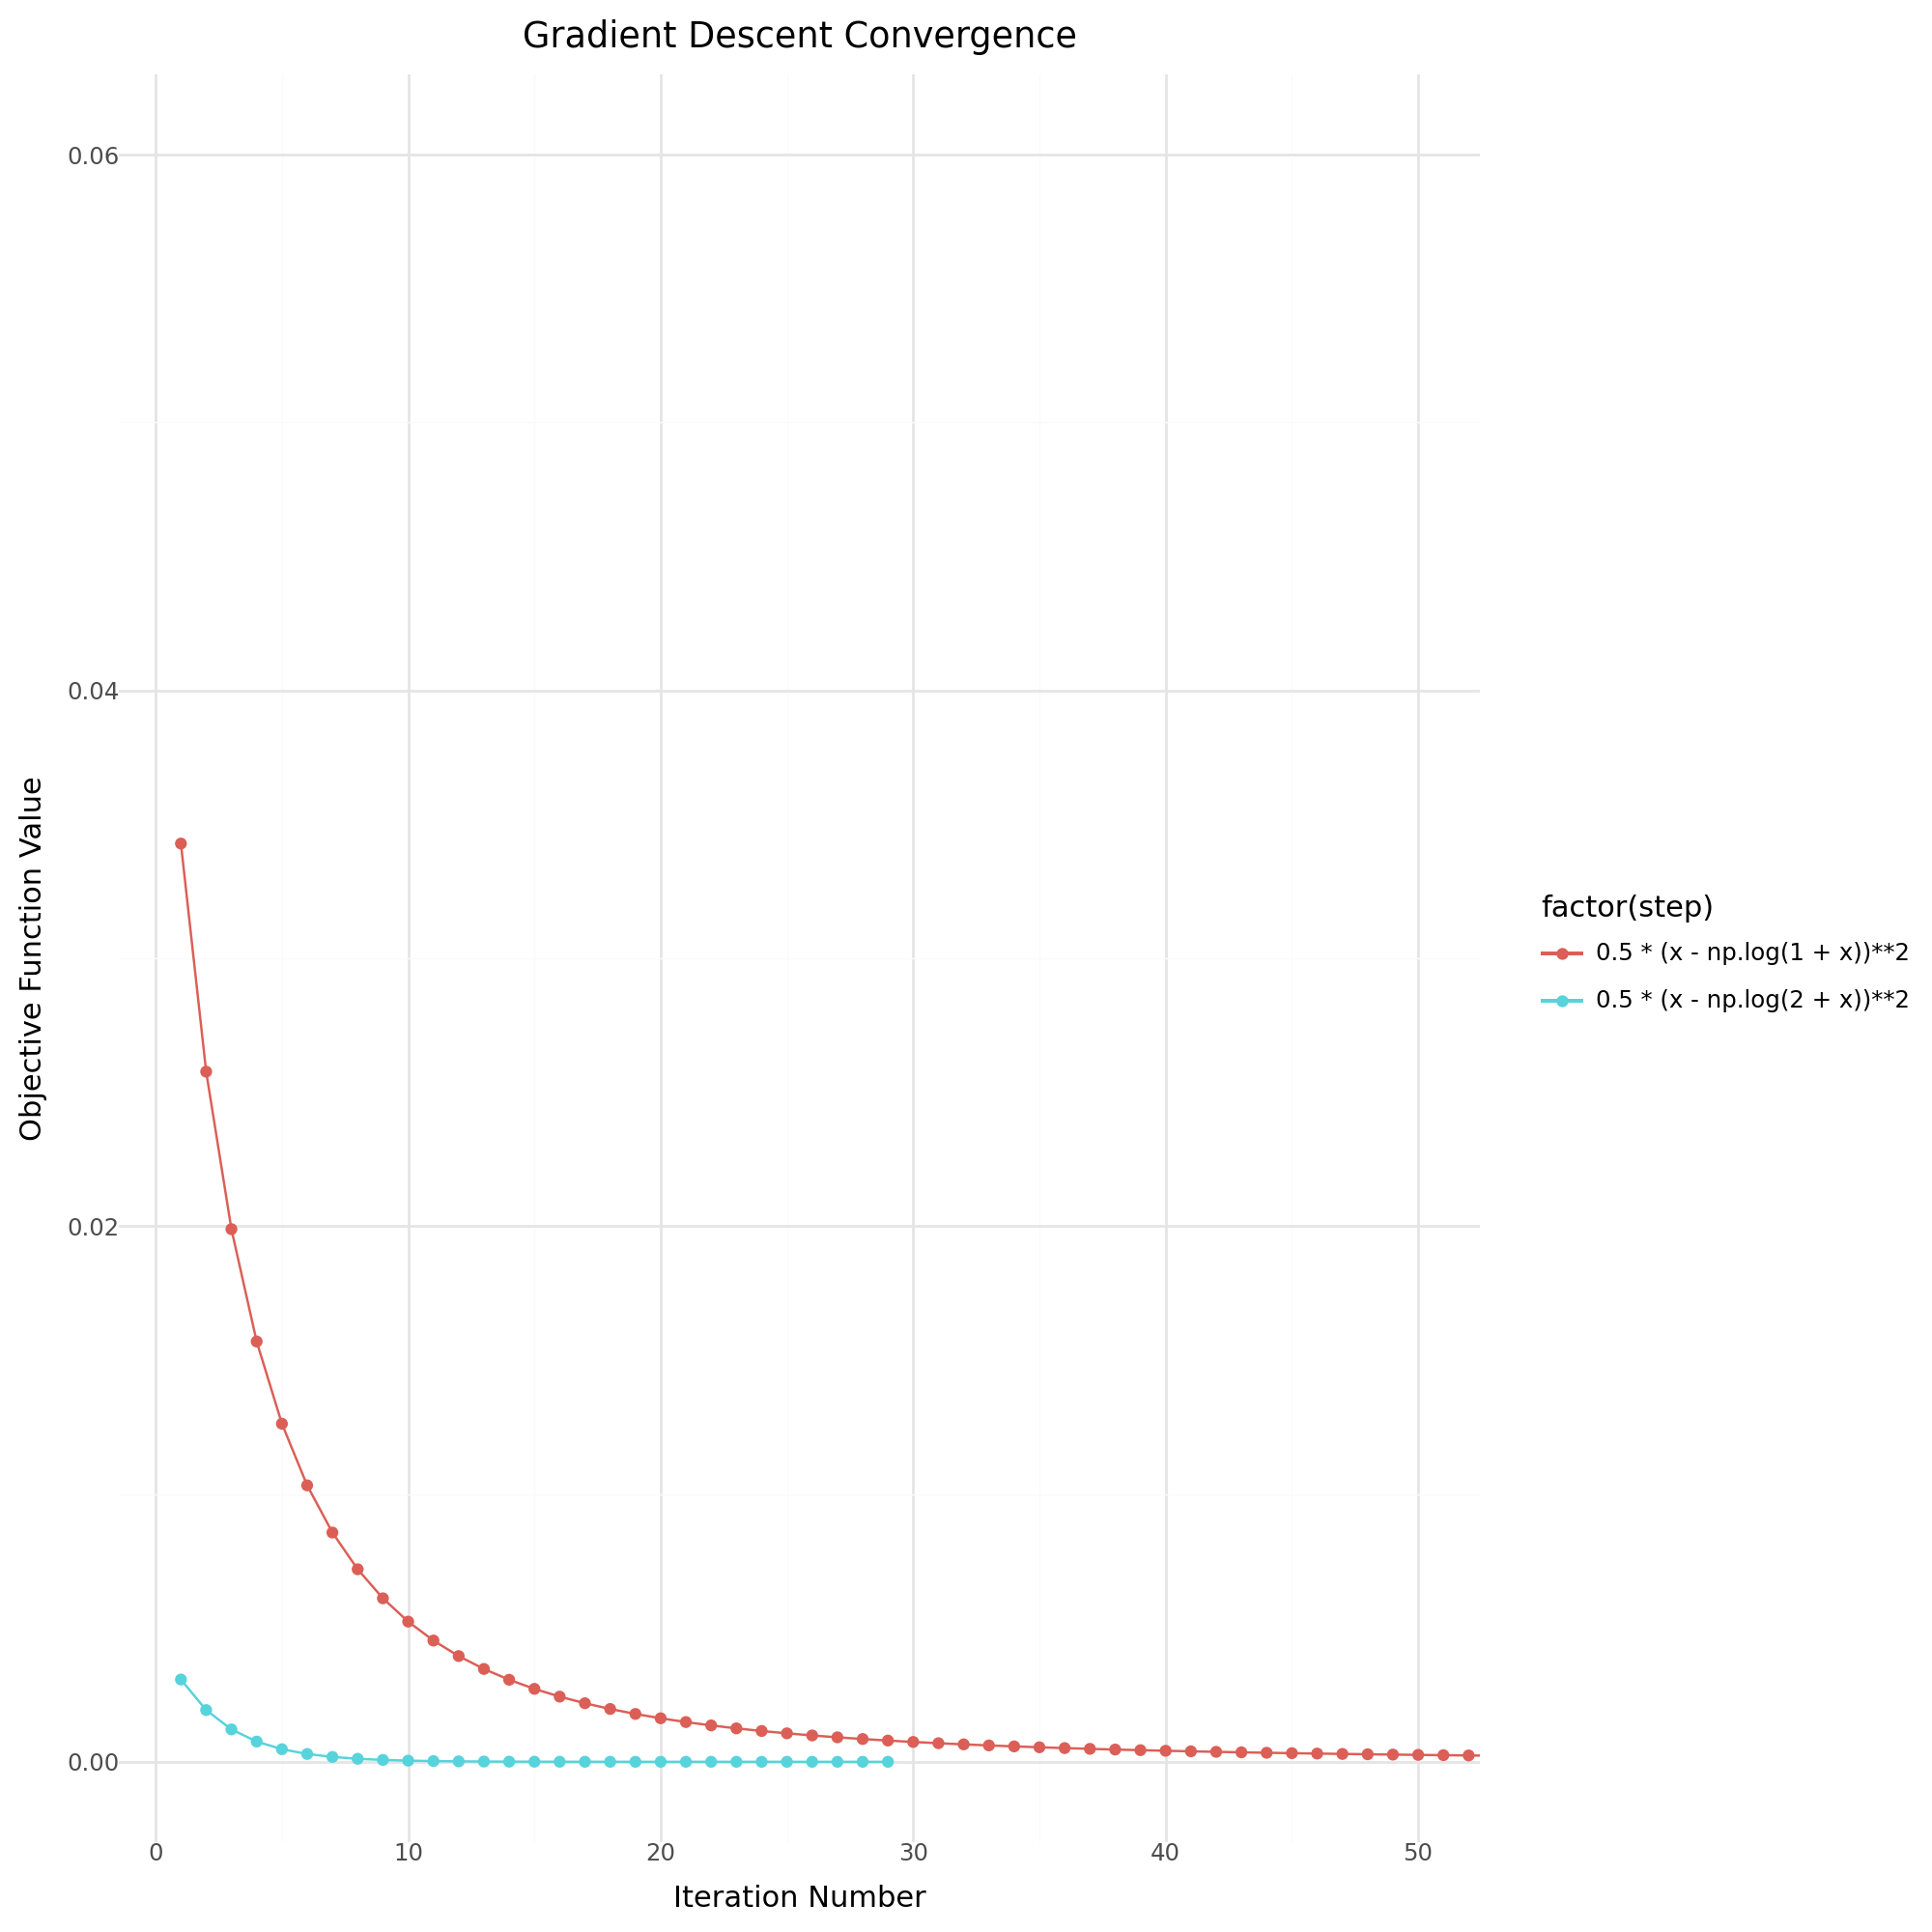

In [100]:

df_1 = pd.DataFrame({
    'iteration': np.arange(1, len(values_1) + 1),
    'objective_value': values_1,
    'step': "0.5 * (x - np.log(1 + x))**2"
})
print('Time for first func:', time_1)
df_2 = pd.DataFrame({
    'iteration': np.arange(1, len(values_2) + 1),
    'objective_value': values_2,
    'step': "0.5 * (x - np.log(2 + x))**2"
})
print('Time for first func:', time_2)
all_objective_values_ln = pd.concat([df_1, df_2], ignore_index=True)

# Plot the results
fig_2 = (ggplot(all_objective_values_ln, aes(x="iteration", y="objective_value", color="factor(step)")) +
         geom_line() +
        geom_point()+
         labs(title="Gradient Descent Convergence", x="Iteration Number", y="Objective Function Value") +
         coord_cartesian(xlim=(1, 50), ylim=(0, 0.06)) +
         theme_minimal() +
         theme(figure_size=(10, 10)))
fig_2

In [94]:
l_1

0.6009229597545602

In [95]:
l_2


0.46027682271151693